# **<span style="color: #000000;background-color: #fff5b1">딥러닝1(IMAGE&SEQUENCE) 사전과제</span>**

### **필수내용**
- 합성곱 신경망 CNN
    - CNN 전체 구조
    - CNN 모델
- 이미지 딥러닝 응용
- RNN
    - RNN 구조와 원리
    - RNN 한계
- LSTM과 GRU
- Seq2Seq
    - Seq2Seq 개념
    - Encoder-Decoder 구조

---

### <span style="color: #000000;background-color: #ffdba4">**1. 합성곱 신경망 (CNN, Convolutional Neural Network)**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **1-(1) CNN 개념**</span> 
- 컴퓨터에서 이미지 인식 방법
    1. 원본 이미지를 픽셀 단위로 구분
    2. 각 픽셀에 대해 RGB 값을 적절히 조합하여 하나의 픽셀마다 색상 정보를 나타냄
    #### <span style="color: #ff0000">   **만약 픽셀 정보들을 그냥 한습한다면?!**</span>
    - 각각의 픽셀을 따로 학습한다면 순서가 뒤섞여서 원본 이미지의 특징이 사라짐   
    => 사람은 이미지 전체의 모든 부분을 하나하나 살펴보지 않음  
    -> 이처럼 <U>**이미지 공간정보를 유지한 상태로 학습이 가능한 방식**</U> = **CNN**

#### <span style="color: #000000;background-color: #ffc2e5">   **1-(2) 이미지 처리에 MLP 대신 CNN 사용 이유**</span> 
**1. 이미지 구조 유지**
- 이미지는 픽셀 간의 공간적 관계가 중요
    - MLP : 픽셀을 일렬로 펼쳐 처리
    - CNN : 이미지의 2차원 구조를 유지한 채 주변 픽셀 관계와 시각적 특징을 학습  
    => 따라서 CNN이 더 적합
  
**2. 위치,크기,회전 등의 변화에 적합**
- MLP의 문제
    - 위치가 아주 조금만 움직여도 입력값이 많이 변해서 학습한 가중치가 무력화되는 문제 발생  
        => 위치 변화에 따른 숫자 인식 성능이 크게 저하됨
- CNN
    - convolution으로 특징 추출 : 모델이 특징 학습
    - Pooling으로 차원 축소 : 위치/크기 변화에 덜 민감  
        => 어떤 영역에 특정한 특징이 존재하는가를 확인 = 위치에 무관'

**3. 효율적인 파라미터 사용**
 - MLP의 문제점
    - 완전연결 구조로 인한 파라미터 급증
    - 가중치 수가 이미지 픽셀 수만큼 생성  
        => 과적합 가능성 상승, 이미지가 클수록 학습 속도 저하
- CNN
    - 부분연결 구조 & Convolution 연산으로 이미지의 특정 피처에 집중

**4. 공간 정보 손실**
 - MLP의 한계
    - 이미지를 1차원 벡터로 바로 변환
    - 2차원 이상의 이미지를 1차원으로 flatten  
    => 이 과정에서 이미지의 공간 정보 손실이 큼!
- CNN
    - 다차원 이미지를 그대로 입력받고, 공간 정보를 보존하면서 학습
    - 특징을 어느정도 추출한 후 flatten => 손실률이 훨씬 낮음
     

#### <span style="color: #000000;background-color: #ffc2e5">   **1-(3) 합성곱(Convolution)과 풀링(Pooling)**</span> 
<U>**이미지의 특징을 추출하는 방법**</U>
- 이미지 데이터는 일반적인 텍스트나 수치 데이터와 달리 공간적 관계와 지역적 패턴 중요 => CNN 사용

##### <span style="color: #27baff">   **[CNN 모델의 구조]** <span>
- **특징 추출 영역**
    - Convolution Layer : 입력 데이터에 필터를 적용 후 활성화 함수를 반영하는 필수 요소
    - Pooling Layer : Convolution Layer 다음에 위치하며, 이미지의 공간 크기를 줄여 중요한 특징 강조
- **이미지 분류 영역**
    - CNN 모델의 마지막에 위치
    - Fully Connected Layer로 구성
- 두 영역 사이에 3차원->1차원 배열로 만드는 Flatten 위치

##### <span style="color: #27baff">   **[특징 추출(Feature Learning)]** <span>
**1. Convolution Layer**  
- 전체 이미지를 일정 크기의 필터로 훑으면서 이미지의 특징 학습  
    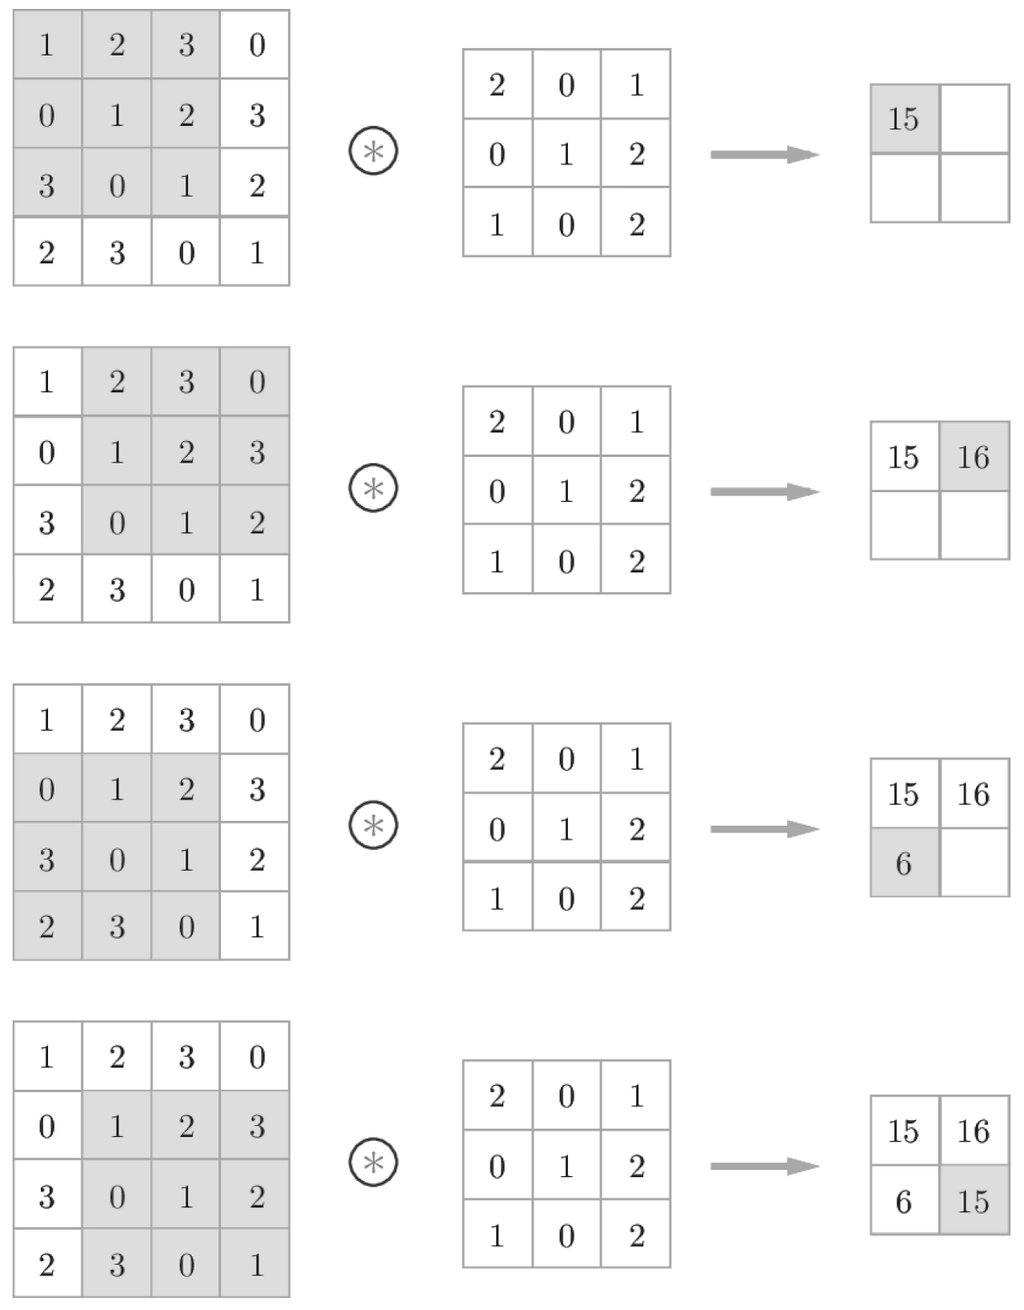  
    (1) 필터 또는 커널이 이미지 위를 슬라이딩
    - CNN의 필터 값 = MLP의 가중치   

    (2) 각 위치에서 요소별 곱셈 후 합계 계산   
    (3) 결과를 Feature Map(activation map)에 저장   
    - feature map : input에 필터를 적용하여 얻은 결과물
    - feature map의 차원 : 필터 수에 따라 결정

**2. Padding**
- 필터를 거치며 정보를 잃어버리는 것을 막기 위해 이미지 바깥을 0으로 둘러싸는 기법  
    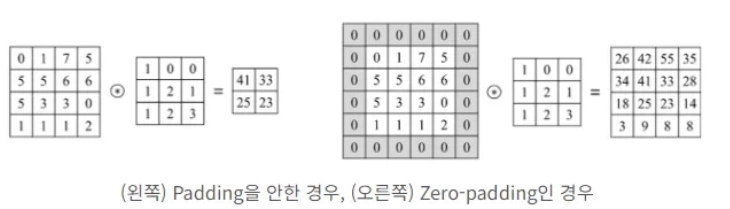  
    - 이미지의 크기를 유지하면서 가장자리 특징까지 반영 가능

**3. Stride(보폭)**
 - 이미지를 몇칸씩 점프하면서 훑을 것인지 결정하는 값  
    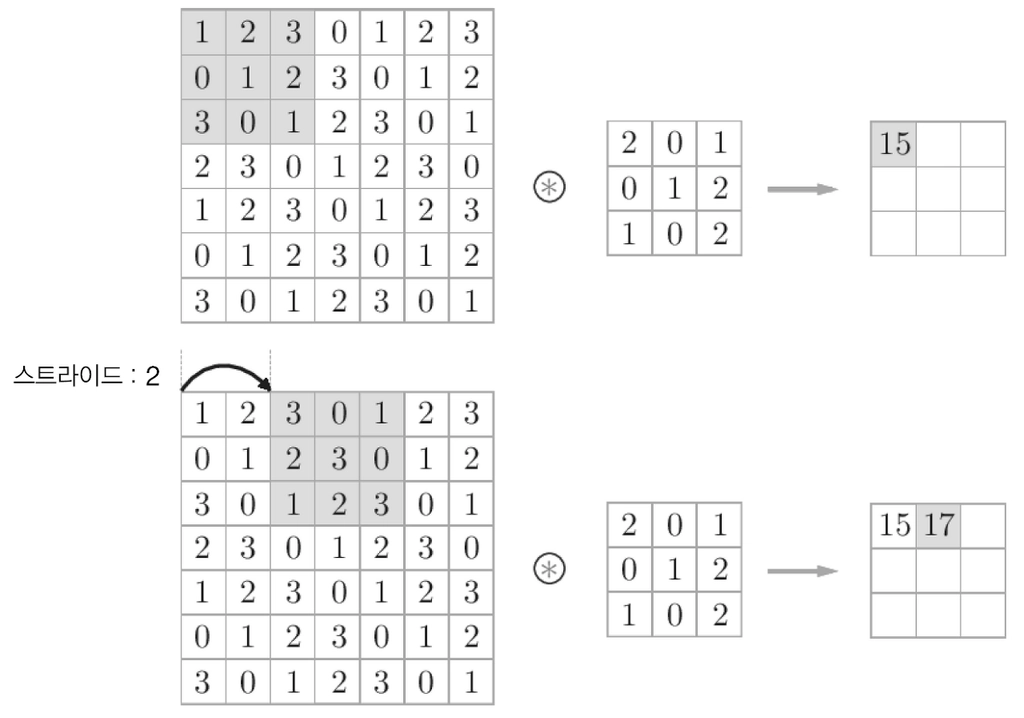  
    - Stride = 1: 한 칸씩 이동 (세밀한 특징 추출)
    - Stride = 2: 두 칸씩 이동 (빠른 처리, 크기 축소)  
    => 보폭이 클수록 feature map의 크기가 작아짐

**4. Pooling**
- feature map에서 특징을 추출하기 위해 이미지를 격자 형태로 분할한 뒤, 해당 영역 안에서 가장 큰 값 또는 평균값을 취하는것  
    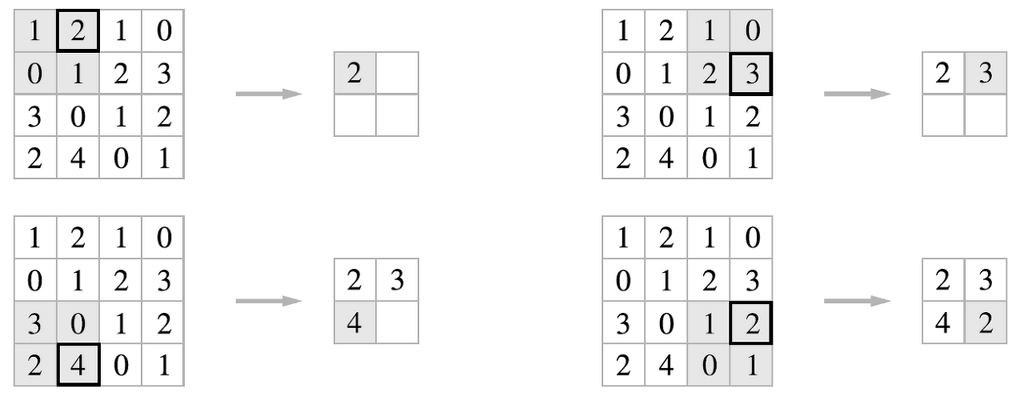  
- 종류
    - Max Pooling : 최댓값 선택 (대부분 사용)
    - Average Pooling : 평균값 선택

| **장점** | **단점** |
| --- | --- |
| 차원을 축소시켜 모델 용량과 계산량이 감소 | 정보 소실의 위험이 있음 |
| 노이즈를 제거하고 중요한 데이터(피처)만 유지 |  |
| 불필요한 정보를 제거해 과적합 방지 |  |

#### <span style="color: #000000;background-color: #ffc2e5">   **1-(4) 대표적인 CNN 아키텍쳐**</span> 
- AlexNet(2012)
    - 머신러닝에서 벗어나 최초로 GPU를 이용해 학습한 대규모 CNN 모델
    - 5개의 Convolutional Layer + 3개의 Fully Connected Layers  
     => 총 8층 구조
    - ReLU 사용 -> 기울기 소실 문제 해소
    - Dropout을 통한 과적합 방지
- VGGNet(2014)
    - 이미지 인식에 강한 깊은 층의 CNN 모델
    - Conv+max Pooling 여러번 반복
    - 필터 크기 : 3*3 고정
    - 전이학습에 많이 쓰임
- ResNet(2015)
    - 잔차 연결 개념을 도입해 깊은 신경망의 소실 문제를 해결한 모델
    - 잔차 연결이란?
        - 이전 레이어의 출력을 몇 레이어를 건너뛰고 다음 레이어의 입력으로 직접 추가하는 방식
        - 층을 깊게 쌓아도 기울기 소실문제 X

### <span style="color: #000000;background-color: #ffdba4">**2. 이미지 딥러닝 응용**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(1) 이미지 분류(Image Classification)**</span> 
##### <span style="color: #27baff">   **[아이디어]** <span>
- 이미지를 수치 데이터로 인식 -> 사전 정의된 클래스 중 하나로 분류

##### <span style="color: #27baff">   **[모델별 정리]** <span>
| 모델명 | 특징 요약 | 주의사항 |
| --- | --- | --- |
| **AlexNet** | 비교적 단순한 구조, 초기 CNN 모델들 | 작은 데이터셋이나 학습 개념 설명용으로 적절 |
| **VGG** | 더 깊은 구조, 복잡한 블록 구조 적용 | 계산량 증대, 메모리 요구 높음 |
| **ResNet** | Residual 연결 (skip connections) → 매우 깊은 네트워크 가능 | 과적합 주의, batch size / regularization 조절 필요 |
| **Vision Transformer (ViT)** | Transformer 구조 응용 → 패치 기반 입력 처리 | 이미지와 순차 처리 모델의 결합, 대규모 데이터 필요 |

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(2) 객체 탐지(Object Detection)**</span> 
##### <span style="color: #27baff">   **[아이디어]** <span>
- 객체 검출 : 한 이미지에서 객체와 이 객체를 둘러싸는 가장 작은 직사각형으로 정의되는 bounding box를 찾는 작업

##### <span style="color: #27baff">   **[모델 적용 방식]** <span>
- CNN을 통해 피쳐맵을 얻고, 그 위에 두가지 head를 올림
    - Classification Head : 객체의 클랙스 예측
    - Regression Head : 객체의 위치(x,y,width,height) : 좌표 예측
- 대표 모델 : YOLO, Faster R-CNN,SSD 등

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(3) 이미지 캡셔닝(Image Captioning)**</span> 
##### <span style="color: #27baff">   **[아이디어]** <span>
- 이미지 캡셔닝 : 이미지 내에 있는 객체에 대한 판단 뿐만 아니라 객체들 간의 관계를 파악하고 자연어의 형태로 알맞게 표현 

##### <span style="color: #27baff">   **[모델 적용 방식 : CNN과 RNN]** <span>
- CNN(이미지 특징 추출) + RNN(문장으로 나타냄)

##### <span style="color: #27baff">   **[이미지 캡셔닝 단계]** <span>
1. CNN을 이용한 특징 추출
    - RGB 3채널의 인풋 데이터를 ResNet-101을 이용해 특징 추출
2. Attention Network를 이용하여 단어 생성
    - 중요한 부분에 가중치를 두어 단어 추출
    - 가중치가 높은 부분을 이용해 사진을 한 문장으로 설명할 수 있게 함
3. RNN을 이용하여 문장 완성
    - 가중치를 바탕으로 추출해낸 이미지의 주요 단어들을 RNN을 통해 조합하여 문장 완성

### <span style="color: #000000;background-color: #ffdba4">**3. RNN(Recurrent Neural Network)**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **3-(1) 순차(Sequence) 데이터란?**</span> 
<U>**순서에 의미가 있으며, 순서가 달라질 경우 의미가 손상되는 데이터**</U>

##### <span style="color: #27baff">   **[순차 데이터의 예시]** <span>
- 음성 및 오디오 데이터
    - 소리의 파형 : 시간에 따라 변화하는 순차 데이터
- 자연어
    - 문장, 단락, 문서 : 단어의 순서가 매우 중요한 순차데이터
- 생물학적 서열 데이터
    - DNA, 단백질 서열 : 특정 순서로 배열된 순차 데이터
- 비디오 데이터
    - 여러 이미지 프레임이 순서대로 나열된 순차 데이터

##### <span style="color: #27baff">   **[기존 정형 데이터와의 차이점]** <span>
- 기존 정형 데이터
    - 샘플(행)의 독립성 
        - 각 행은 독립적인 정보
        - 행의 순서가 바뀌어도 데이터셋의 의미 변화 X
    - 특성(열)의 독립성
        - 특성을 분석하는 순서가 달라져도 각 특성이 담고 있는 정보는 동일
- 순차 데이터
    - 요소의 순서 의존성   
        - 데이터를 구성하는 요소들의 순서 자체가 핵심 정보
    - 자기상관성
        - 이전 시점의 데이터가 다음 시점의 데이터에 영향

=> 기존의 머신러닝 기법으로는 순차 데이터의 특징 고려 X  
=> 과거의 정보를 기억하고, 순서의 의미를 학습할 수 있는 특별한 신경망이 필요함! (=**RNN**)

#### <span style="color: #000000;background-color: #ffc2e5">   **3-(2) RNN의 구조와 원리**</span> 
##### <span style="color: #27baff">   **[RNN의 정의]** <span>
<U>**순환하는 구조를 가진, 순차 데이터 처리에 특화된 인공 신경망**</U> 

1. 시퀀스 데이터를 입력받아 순서 정보를 유지하며 처리
2. 순환하는 은닉층이 매 시점의 은닉 상태 업데이터
3. 이전 시점의 값을 현재 시점으로 넘겨줌

##### <span style="color: #27baff">   **[RNN의 구조]** <span>  
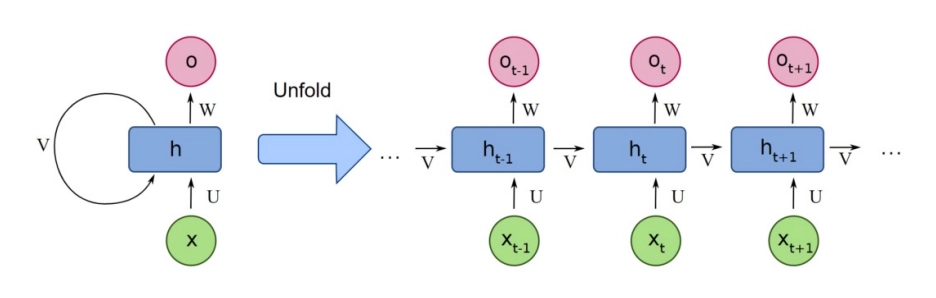

- 초록색 : 입력층, 파란색 : 은닉층, 분홍색 : 출력층
- 용어 설명
    - $x_t$ : 시간 t에서의 입력
    - $h_t$ : 시간 t에서의 은닉상태 (=이 상태의 메모리)
    - $d_t$ : 시간 t에서의 출력
    - $U$ (입력 가중치) : 현재 시점의 입력이 은닉상태에 영향을 주는 가중치
    - $V$ (순환 가중치) 
        - 이전 시점의 은닉 상태가 현재 은닉상태에 영향을 주는 가중치
        - 기존 신경망과의 차이점
    - $W$ (출력 가중치)
        - 현재 시점의 은닉상태가 최종출력에 영향을 미치는 가중치
        - 계산된 메모리를 바탕으로 결과를 만들어내는 역할
- 정보 흐름
    - t-1 시점 : 입력이 들어가서 은닉상태를 업데이트하고 출력을 내보냄
    - t 시점 
        - t-1 시점에서 계산된 은닉상태가 다음 시점으로 그대로 전달
        - 새로운 입력과 전달받은 과거 정보(t-1의 은닉상태)를 함께 사용하여 현재 시점의 은닉상태를 업데이트하고, 출력 계산  
    => 은닉상태의 순환을 통해 과거의 정보를 다음 시점으로 계속해서 전달

##### <span style="color: #27baff">   **[RNN의 핵심 원리 : 가중치 공유]** <span>  
- 동일한 가중치를 시퀀스의 다양한 시점에서 반복적으로 적용
- RNN이 시퀀스 데이터의 길이와 시점 위치에 상관없이 효과적으로 작동하게 하는 핵심 원리
- 다른 입력들을 처리할 때까지 모두 동일한 파라미터(입력 가중치, 순환 가중치, 편향)을 공유하는 구조
- 장점
    - 학습 파라미터의 수 감소
        - 학습해야 할 파라미터 수가 일정하게 유지 = 모델이 더 빠르고 가벼워짐
    - 일반화 능력 향상
        - RNN은 '이전 시점까지의 정보와 현재 시점의 입력이 주어졌을 때, 어떻게 상태를 업데이트할 것인가?'라는 하나의 일반적 규칙 학습
        - 새로운 시퀀스나 다양한 패턴에도 유연하게 대응 가능

#### <span style="color: #000000;background-color: #ffc2e5">   **3-(3) RNN의 한계 및 장기 의존성 문제**</span> 
##### <span style="color: #27baff">   **[RNN의 한계점]** <span>  
- RNN 구조 특성 상 전체 시퀀스를 모두 읽은 후 역전파가 이루어짐
- 역전파를 구하는 과정에서 연쇄법칙에 의해 다음 미분값이 반복적으로 곱해짐

**1. 기울기 소실**
- 시퀀스 뒤쪽의 오차가 앞쪽까지 제대로 전달되지 않아 먼 과거의 정보를 학습하지 못하는 현상
- 역전파 과정에서 반복적으로 곱해지는 기울기(미분값)의 크기가 1보다 작을 때 기울기가 0으로 수렴

**2. 기울기 폭주**
- 시퀀스 뒤쪽의 오차가 역전파 과정에서 비정상적으로 커지는 문제
- 역전파 과정에서 반복적으로 곱해지는 기울기(미분값)의 크기가 1보다 클때 기울기가 무한대로 발산

**3. 느린 훈련 시간**
- 계산 과정이 순차적으로 이루어져야만 하는 구조적 한계
- t 시점의 은닉상태를 계산하려면 t-1 시점의 은닉 상태가 먼저 계산되어야함  
=> 전체 시퀀스를 한번에 병렬 처리 불가

##### <span style="color: #27baff">   **[장기 의존성 문제]** <span> 
- 위 세가지 구조적 한계 => '장기 의존성 문제'로 이어짐
- 장기 의존성 문제란?
    - 시퀀스 앞 부분의 중요한 정보를 잊어버려 맥락 파악 능력이 급격히 저하되는 현상
    - 모델의 단기 기억력은 준수했지만 장기기억력에 문제 발생

##### <span style="color: #ff0000">   **=> 새로운 모델이 필요하다!** <span>
- RNN의 기억력 한계 극복
- 더 길고 복잡한 시퀀스 데이터를 안정적으로 다룰 수 있는 새로운 대안
- 중요한 정보는 오래 기억하고, 불필요한 정보는 잊는 똑똑한 메모리 구조

### <span style="color: #000000;background-color: #ffdba4">**4. LSTM&GRU**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **4-(1) LSTM(Long Sort Term Memory)**</span> 
<U>**RNN의 기울기 소실 문제를 해결하기 위한 모델 구조**</U>

- 셀상태 $C_t$ - 장기기억 : 절대 변하지 않는 핵심 기억
- 엘리트 (은닉상태$h_t$ - 단기기억/출력)
    - 현재 상황에서 바로 사용하는 기억
    - 지금 시점에서의 판단이나 출력으로 사용
- LSTM 행동 방식
    1. 핵심 아이디어 : 기억할 내용과 잊어버릴 내용을 선택해서, 중요한 정보들을 오래 가져간다 -> 'GATE'를 통해 곱셈을 덧셈으로 바꾼다
    2. RNN과의 주요 차이 : ct와 ht의 2개의 순환되는 층을 사용
    3. Gate를 통해 필요한 정보들만 통과
        - Forget gate : 정보를 얼마나 잊어버릴지 결정
        - Input gate : 현재 정보를 얼마나 사용할지 결정
        - Output gate : 다음 층으로 어떤 정보를 전달할지 결정(hidden state 생성)
    4. Final memory cell : input, forget gate를 결합해 현재 정보를 얼마나 기억할지 계산
- 장점
    - Vanishing gradient problem 효과적으로 완화
- 단점
    - 많이 복잡한 구조, RNN보다 학습 파라미터가 많아짐

#### <span style="color: #000000;background-color: #ffc2e5">   **4-(2) GRU**</span> 
<U>**LSTM에서 조금 더 발건한 것으로 별도의 메모리 셀 없이 게잍트 수를 줄여 구조를 간소화함**</U>

- LSTM과의 차이점
    - forget gate와 input gate를 update gate 하나로 합침
    - reset gate 사용
    - gate의 개수가 3개->2개로 줄어 학습 시간이 줄어듦  
     -> 시간은 줄어들지만 성능은 LSTM과 유사하더나 더 좋음
    
- 장점 : 성능과 효율성 사이의 균형이 좋다
- 단점 : 긴 시퀀스 처리에서의 한계는 여전히 존재

#### <span style="color: #000000;background-color: #ffc2e5">   **4-(3) LSTM과 GRU 비교**</span> 

| 구분 | LSTM | GRU |
| --- | --- | --- |
| **구조** | 3개 게이트 (입력, 삭제, 출력) | 2개 게이트 (업데이트, 리셋) |
| **복잡도** | 더 복잡, 파라미터 수 많음 | 단순, 파라미터 수 적음 |
| **학습 속도** | 느림 (계산량 많음) | 빠름 (계산량 적음) |
| **메모리 사용량** | 큼 | 작음 |
| **장기 의존성 처리** | 더 강력 | LSTM과 비교해 다소 약함 |
| **연구/사례 축적** | 매우 많음 | 비교적 적음 (최근 등장) |
| **성능** | 데이터가 충분하고 문제 복잡성이 높을 때 강력 | 데이터가 적거나 효율성이 중요할 때 유리 |

- LSTM이 적합한 경우
    - 긴 시퀀스에서 문맥 이해가 중요한 작업
    - 데이터 양이 충분하고 복잡한 패턴을 학습해야 하는 경우
    - 모델 성능이 계산 효율보다 더 중요한 경우
    - 기계 번역, 언어 모델링, 장기 시계열 예측
- GRU가 적합한 경우
    - 자원이 제한적이거나 학습 속도가 중요한 경우
    - 데이터 양이 적고 과적합 위험이 있는 경우
    - 실시간 예측이 필요한 응용

### <span style="color: #000000;background-color: #ffdba4">**5. Seq2Seq**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **5-(1) Seq2Seq란?**</span>
<U>**한 시퀀스를 다른 시퀀스로 변환하는 작업을 수행하는 딥러닝 모델로, 대표적으로 기계번역에서 사용됨**</U>

- 특징
    - 아이템(단어)의 입력 개수와 출력 개수가 같지 않아도 됨.
    - 인코더와 디코더라는 모듈을 가지고 있어, Encoder-Decoder 모델이라고도 불림

#### <span style="color: #000000;background-color: #ffc2e5">   **5-(1) 인코더와 디코더**</span> 
##### <span style="color: #27baff">   **[인코더(Encoder)]** <span>
- 입력된 시퀀스를 읽고 압축하여 디코더에게 넘겨줄 문맥 정보 준비(원문의 특징 파악)  
    => 여기서 압축된 정보 = 컨텍스트 벡터(요약 정보)
- t 시점의 임베딩된 단어의 입력과 t-1 시점의 은닉 상태가 RNN/LSTM의 입력으로 주어지며, 그 결과로 t 시점의 은닉 상태가 나옴

##### <span style="color: #27baff">   **[디코더(Decoder)]** <span> 
- 압축된 정보를 바탕으로 원하는 시퀀스를 생성(번역문 생성)
- 기본적인 Seq2Seq에서는 인코더가 보내준 컨텍스트 벡터는 디코더의 첫번째 은닉 상태에 사용됨
- t 시점에 나온 출력값이 그 다음 시점의 입력값으로 넘어감

<br>

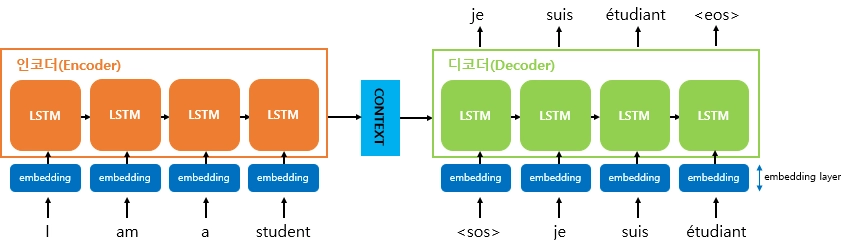
- 인코더와 디코더 모두 RNN을 여러개 조합한 형태
- 모든 단어는 워드 임베딩(word2vec) 과정을 거침
##### <span style="color: #27baff">   **[컨텍스트 벡터(Context Vector)]** <span> 
- float형의 벡터 형태
- 인코더 중 마지막 시점의 은닉 상태를 의미
- 특징
    - 입력 시퀀스의 요약 정보처럼 작동
    - 벡터의 차원을 직접 설정 가능

#### <span style="color: #000000;background-color: #ffc2e5">   **5-(2) Seq2Seq의 한계 : 병목 현상**</span> 
<U>**고정된 컨텍스트 벡터에 소스 문장의 정보를 압축하려고 할 때 병목 현상 발생**</U>

- 고정된 길이에 입력 시퀀스의 모든 정보를 담지 못하고 손실
- 특히 긴 입력 시퀀스의 경우 정보 손실이 더 심각하며, 이는 모델 성능 하락으로 이어짐

<br>

- 추가 한계점
    - 기울기 소실 문제
    - 병렬화 불가능 문제
    
<br>

-> 이러한 한계를 해결하기 위해 Attention 매커니즘 도입